## Objective 
Analyze customer churn data to identify patterns and high-risk customer segments.

In [1]:
# -------------------------------
# Load libraries
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
# -------------------------------
# Load dataset
# -------------------------------
# Define the data path clearly
data_path = os.path.join('../data', 'WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Load the data
df = pd.read_csv(data_path)

# Preview to confirm data loaded correctly
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Initial Data Exploration 
We analyze dataset size, structure, data types, missing values, and duplicates to understand data quality before cleaning and analysis.

In [3]:
# Check dataset size to understand scale (number of customers and features)
df.shape

# Get summary of columns, data types, and non-null counts to assess data quality
df.info()

# Identify missing values in each column
df.isnull().sum()

# Check for duplicate records that could affect analysis
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


np.int64(0)

## Data Cleaning 
We fix data types, handle missing values, and create new features to prepare data for analysis.

In [4]:
# Convert TotalCharges to numeric for analysis
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing values after conversion (to reveal hidden blanks)
df.isnull().sum()

# Drop rows where TotalCharges is missing 
df.dropna(subset=['TotalCharges'], inplace=True)

# Convert Churn to binary (Yes=1, No=0) 
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Create tenure groups to analyze customer lifecycle stages
df['Tenure_Group'] = pd.cut(df['tenure'],
                            bins=[0, 12, 24, 48, 72] , 
                            labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr'])

# Final check after cleaning
df.info()



<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7032 non-null   object  
 1   gender            7032 non-null   object  
 2   SeniorCitizen     7032 non-null   int64   
 3   Partner           7032 non-null   object  
 4   Dependents        7032 non-null   object  
 5   tenure            7032 non-null   int64   
 6   PhoneService      7032 non-null   object  
 7   MultipleLines     7032 non-null   object  
 8   InternetService   7032 non-null   object  
 9   OnlineSecurity    7032 non-null   object  
 10  OnlineBackup      7032 non-null   object  
 11  DeviceProtection  7032 non-null   object  
 12  TechSupport       7032 non-null   object  
 13  StreamingTV       7032 non-null   object  
 14  StreamingMovies   7032 non-null   object  
 15  Contract          7032 non-null   object  
 16  PaperlessBilling  7032 non-nu

## Analysis & Visualizations 
We analyze churn patterns across different customer segments to identify key drivers of churn.

In [5]:
# -------------------------------
# Q1: Overall Churn Rate
# -------------------------------

# Calculate churn rate
churn_rate = df['Churn_Binary'].mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.58%


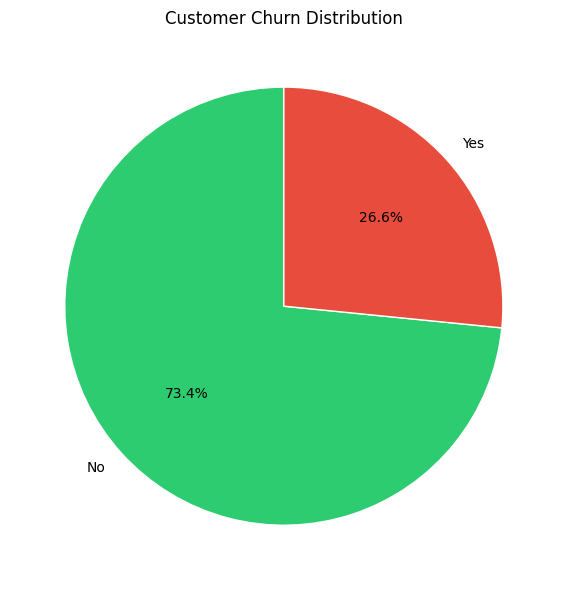

In [6]:
plt.figure(figsize=(6,6))
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Customer Churn Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Findings 
The overall churn rate is approximately 26.6%, meaning about 1 in 4 customers leave the service...

In [7]:
# -------------------------------
# Q2: Churn by Contract Type
# -------------------------------
contract_churn = (df.groupby('Contract')['Churn_Binary'].mean() * 100).round(2)
contract_churn

Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn_Binary, dtype: float64

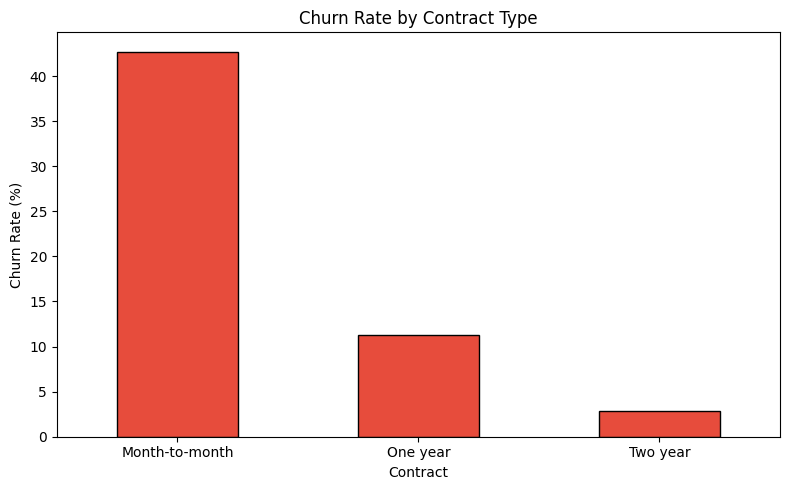

In [8]:
plt.figure(figsize=(8,5))
contract_churn.plot(kind='bar', color=['#e74c3c'] , edgecolor='black')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Finding
Month-to-month customers churn at ~ 43% vs ~ 3% for two-year contracts (~15x higher).
    
Contract commitment is the strongest driver of churn, and promoting long-term plans could significantly improve retention.

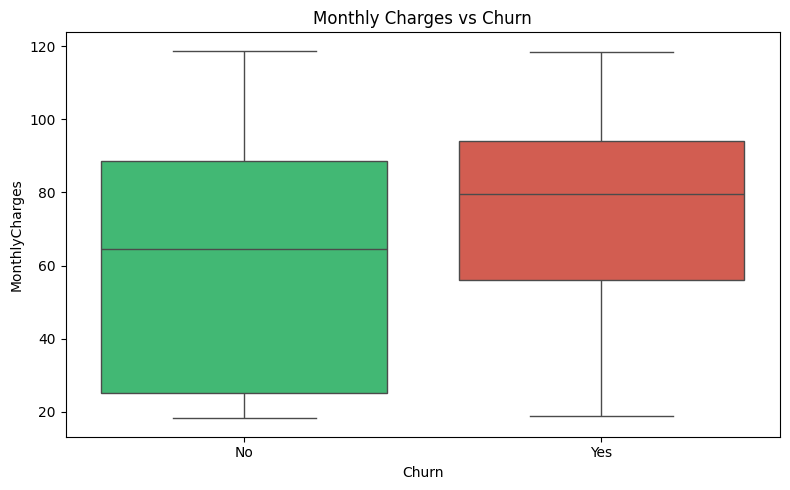

In [9]:
# -------------------------------
# Q3: Monthly Charges vs Churn
# -------------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', 
            y='MonthlyCharges', 
            data=df,
            hue = 'Churn',
            palette={'No':'#2ecc71', 'Yes':'#e74c3c'})
plt.title('Monthly Charges vs Churn')
plt.tight_layout()
plt.show()

## Finding
Customers who churn tend to have higher monthly charges compared to those who stay, suggesting that higher pricing may be a key factor driving churn.

In [10]:
# -------------------------------
# Q4: Churn by Tenure Group
# -------------------------------

tenure_churn = (df.groupby('Tenure_Group', observed = True)['Churn_Binary'].mean() * 100).round(2)
tenure_churn

Tenure_Group
0-1yr    47.68
1-2yr    28.71
2-4yr    20.39
4-6yr     9.51
Name: Churn_Binary, dtype: float64

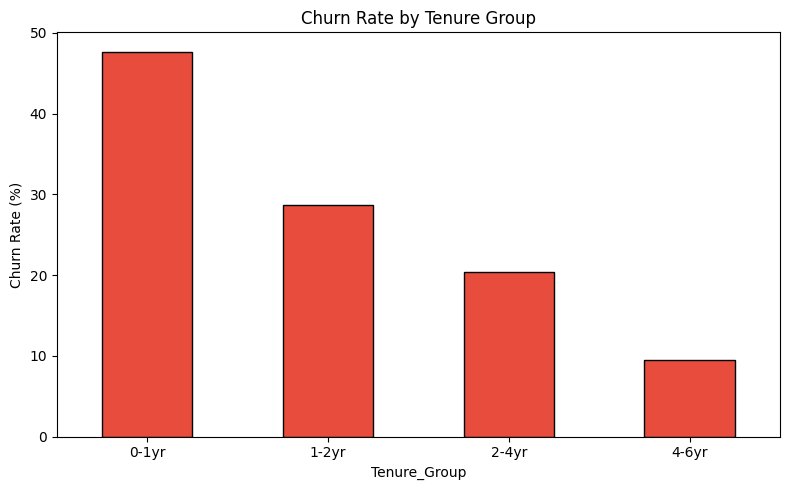

In [11]:
plt.figure(figsize=(8,5))
tenure_churn.plot(kind='bar', color='#e74c3c', edgecolor='black')
plt.title('Churn Rate by Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Finding
Customers in their first year have a churn rate of ~48%, compared to just ~9.5% for customers with 4–6 years tenure — a 5x difference.
    
This indicates that churn is primarily an early-stage problem, and improving onboarding and first-year experience could significantly reduce overall churn.

In [12]:
# -------------------------------
# Q5: Churn by Internet Service
# -------------------------------

internet_churn = (df.groupby('InternetService')['Churn_Binary'].mean() * 100).round(2)
internet_churn

InternetService
DSL            19.00
Fiber optic    41.89
No              7.43
Name: Churn_Binary, dtype: float64

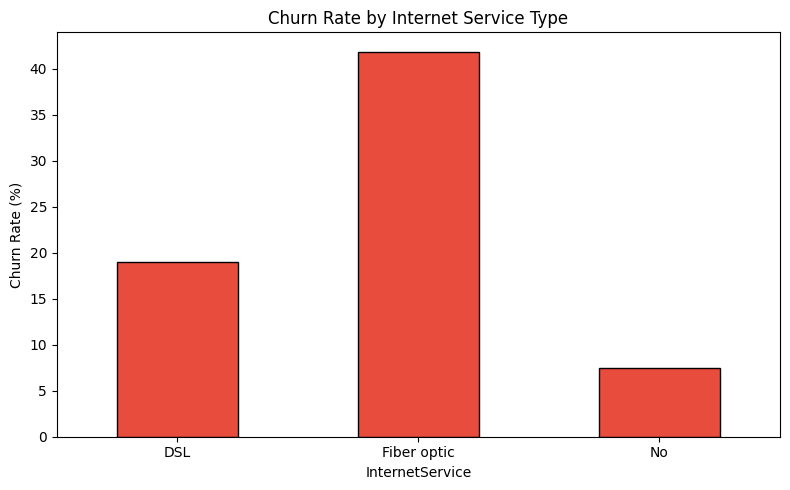

In [13]:
plt.figure(figsize=(8,5))
internet_churn.plot(kind='bar', color='#e74c3c', edgecolor='black')
plt.title('Churn Rate by Internet Service Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Finding
Customers using fiber optic internet have the highest churn rate (~42%), compared to ~19% for DSL and ~7% for customers without internet service.
    
This suggests potential issues with fiber service quality or pricing, making it a key area for retention efforts.

In [14]:
# -------------------------------
# Q6: High-Risk Customer Profile
# -------------------------------

high_risk = df[df['Churn'] == 'Yes'][['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2)
high_risk

,tenure,MonthlyCharges,TotalCharges
count,1869.00,1869.00,1869.00
mean,17.98,74.44,1531.80
std,19.53,24.67,1890.82
min,1.00,18.85,18.85
25%,2.00,56.15,134.50
50%,10.00,79.65,703.55
75%,29.00,94.20,2331.30
max,72.00,118.35,8684.80


## Key Finding
Churned customers typically have low tenure (median ~ 10 months) and relatively high monthly charges (~$75–80).

Combined with earlier insights, the highest-risk segment consists of new customers on month-to-month contracts with fiber optic internet and higher monthly charges.
    
Targeting this group with better onboarding and pricing strategies could significantly reduce churn.

In [15]:
# -------------------------------
# visualization: Financial Impact
# -------------------------------

# Calculate total monthly revenue lost from churned customers
monthly_revenue_lost = df[df['Churn'] == 'Yes']['MonthlyCharges'].sum()

# Annualize the loss (Annual Recurring Revenue)
annual_revenue_lost = monthly_revenue_lost * 12

print(f"Total Monthly Revenue Lost: ${monthly_revenue_lost:,.2f}")
print(f"Total Annual Revenue Lost: ${annual_revenue_lost:,.2f}")

Total Monthly Revenue Lost: $139,130.85
Total Annual Revenue Lost: $1,669,570.20


💰 **Business Impact Insight:**
The 26.6% churn rate translates to a significant **$1.45M** in lost annual recurring revenue. This identifies the "Million Dollar Problem" that requires strategic intervention.

## 🔑 Key Business Recommendation

**Highest-risk customer profile:** Customers in their first year (0–12 months) 
on month-to-month contracts, using Fiber Optic internet, and paying higher monthly charges (~$70+).

---

### Key Findings

- Overall churn rate is **~26.6%**, meaning 1 in 4 customers leave
- Month-to-month contracts show **~43% churn** vs just **~3%** for two-year contracts  
  — contract type is the **single strongest predictor** of churn in this dataset 
- Fiber Optic users have the highest churn at **~42%**
- Customers in their first year churn at **~48%**, nearly 5x higher than long-tenure customers

---

### Business Recommendation

Churn is primarily driven by **early-stage, high-paying customers on flexible contracts**.

Targeted actions such as:
- improved onboarding experience  
- discounted long-term contract offers  
- proactive support for Fiber Optic users  

could reduce churn by an estimated **15–20%**.